In [216]:
%load_ext autoreload
%autoreload 2 
    
from __init__ import PRP; import sys
sys.path.append(PRP + 'Diffusion_model')
sys.path.append(PRP + 'Results/analysis_scripts/')

from pipelines.pipeline_tensor import DDPMPipeline_Tensor
from pipelines.constraints import *
from visualisation_utils import State

import torch, os
dl, s = 4, 7

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [261]:
config = TrainingConfig()
config.data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar'

In [262]:
config

TrainingConfig(data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar', gradient_accumulation_steps=1, learning_rate=0.0001, lr_warmup_steps=0, mixed_precision='no', seed=0, use_LDM=False, use_ema=False, base_output_dir='../../diffModel_experiences', lr_schedule='cosine_schedule', st_path=None, generation_frequency=50, pretrained_model_path=None, train_batch_size=8, train_steps_by_epoch=200, eval_batch_size=8, num_train_timesteps=1000, num_inference_steps=1000, num_epochs=5000, output_dir='wandb', fields={'toce': slice(0, -1, 2), 'soce': slice(0, -1, 2), 'ssh': slice(0, 1, None)}, normalisation='3-std')

In [263]:
train_dataloader = get_dataloader(config.data_file,
                                  batch_size=1,
                                  fields=config.fields,
                                  normalisation=config.normalisation, shuffle=False)

idt = iter(train_dataloader)

Data = State('data', config)
Data.normalized =  next(idt)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar
Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [264]:
model_path = f'{os.environ["OCEANDATA"]}/models/dino-fusion/tav0h83b/'
beta = 1.0
beta_type = 'constant'
inf_steps = 1000

In [265]:
pipeline = DDPMPipeline_Tensor.from_pretrained(model_path).to('mps')

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

In [266]:
N = 5
Noisy = State('noisy', config)
clean = Data.normalized.repeat((N,1,1,1))
ts = torch.linspace(0, 999, N).to(int)
Noisy.normalized = pipeline.scheduler.add_noise(Data.normalized, torch.randn_like(Data.normalized), ts)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


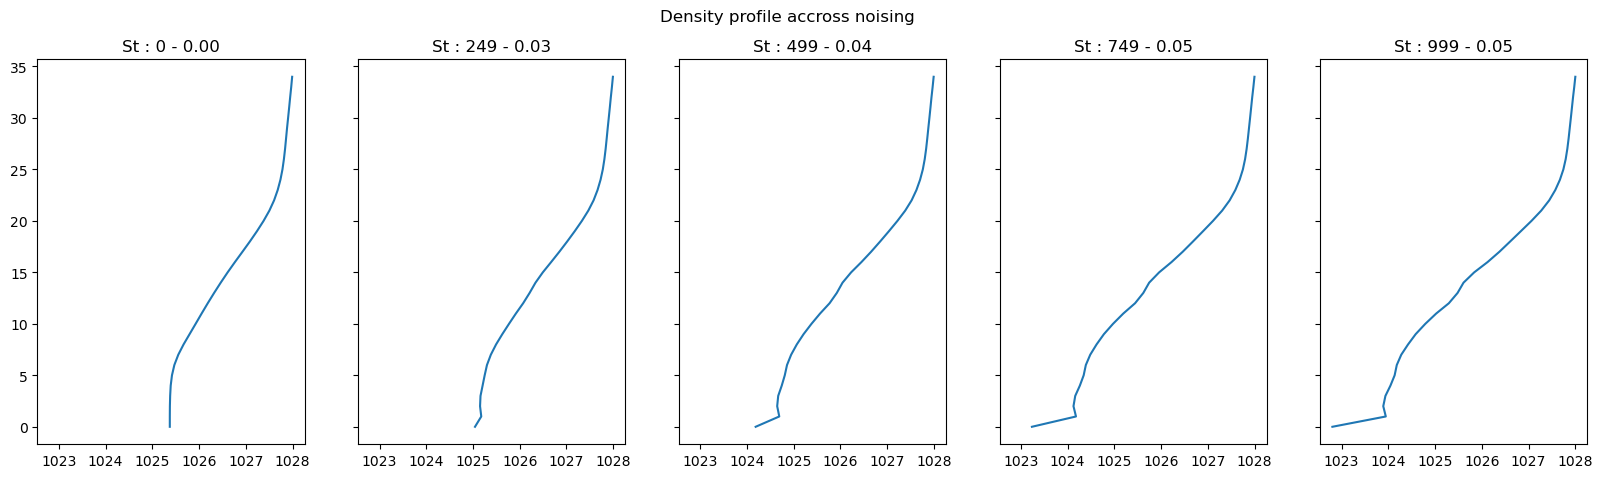

In [267]:
fig, axs = plt.subplots(1, N, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Density profile accross noising')
dpf =  Noisy.density.nanmean(axis=(-2, -1))
dpg =  Noisy.density_gradient.nanmean(axis=(-2, -1))
for i in range(N) :
    axs[i].plot(dpf[i], torch.arange(len(dpf[i])))
    axs[i].set_title(f'St : {ts[i]} - {dpg[i].clamp(0.0).nansum():.2f}')

In [285]:
x = Noisy.normalized.clone().detach()
x.requires_grad_(True)
opt = torch.optim.LBFGS([x], history_size=10, max_iter=4, line_search_fn='strong_wolfe')
def closure() :
    opt.zero_grad()
    samples =  get_transformed_data(x, function=Noisy.unnormalizer)
    density = get_density_at_surface_tensor(samples['toce.npy'], samples['soce.npy'], tmask=None)
    density_profile = density.nanmean(dim=(-2, -1))
    grad_density = (density_profile[:,:-1] - density_profile[:,1:])
    loss = grad_density.clamp(0.0).nansum()
    loss.backward()
    return loss

for i in range(10) :
    print(opt.step(closure))

tensor(0.1782, grad_fn=<NansumBackward0>)
tensor(0.1776, grad_fn=<NansumBackward0>)
tensor(0., grad_fn=<NansumBackward0>)
tensor(0., grad_fn=<NansumBackward0>)
tensor(0., grad_fn=<NansumBackward0>)
tensor(0., grad_fn=<NansumBackward0>)
tensor(0., grad_fn=<NansumBackward0>)
tensor(0., grad_fn=<NansumBackward0>)
tensor(0., grad_fn=<NansumBackward0>)
tensor(0., grad_fn=<NansumBackward0>)


In [290]:
NoisyCorrected = State('corrected', config)
NoisyCorrected.normalized = x.detach()

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


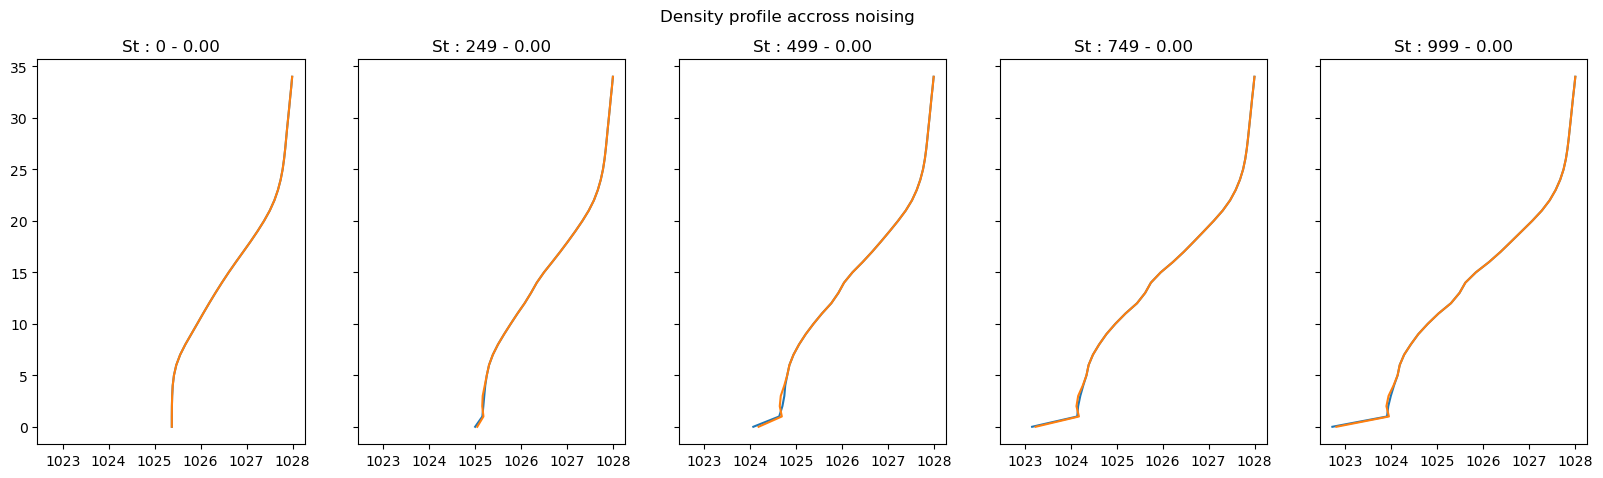

In [294]:
fig, axs = plt.subplots(1, N, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Density profile accross noising')
dpf_c = NoisyCorrected.density.nanmean(axis=(-2, -1))
dpg_c = NoisyCorrected.density_gradient.nanmean(axis=(-2, -1))

dpf =  Noisy.density.nanmean(axis=(-2, -1))
dpg =  Noisy.density_gradient.nanmean(axis=(-2, -1))
for i in range(N) :
    axs[i].plot(dpf_c[i], torch.arange(len(dpf_c[i])))
    axs[i].plot(dpf[i], torch.arange(len(dpf[i])))
    axs[i].set_title(f'St : {ts[i]} - {dpg_c[i].clamp(0.0).nansum():.2f}')

In [295]:
dpf_c[-1] 

tensor([1022.7154, 1023.9046, 1023.9315, 1023.9869, 1024.0553, 1024.1346,
        1024.1807, 1024.2764, 1024.4218, 1024.5851, 1024.7910, 1025.0237,
        1025.2947, 1025.4812, 1025.6089, 1025.8368, 1026.1235, 1026.3765,
        1026.6071, 1026.8357, 1027.0630, 1027.2719, 1027.4431, 1027.5728,
        1027.6720, 1027.7455, 1027.7952, 1027.8303, 1027.8575, 1027.8815,
        1027.9055, 1027.9288, 1027.9520, 1027.9779, 1028.0013,       nan])

In [296]:
dpf[i]

tensor([1022.8024, 1023.9454, 1023.8912, 1023.9374, 1024.0450, 1024.1346,
        1024.1807, 1024.2764, 1024.4218, 1024.5851, 1024.7910, 1025.0237,
        1025.2947, 1025.4812, 1025.6089, 1025.8368, 1026.1235, 1026.3765,
        1026.6071, 1026.8357, 1027.0630, 1027.2719, 1027.4431, 1027.5728,
        1027.6720, 1027.7455, 1027.7952, 1027.8303, 1027.8575, 1027.8815,
        1027.9055, 1027.9288, 1027.9520, 1027.9779, 1028.0013,       nan])

# Looking at individual profiles

IndexError: The shape of the mask [2080750] at index 0 does not match the shape of the indexed tensor [5, 35, 12338] at index 0

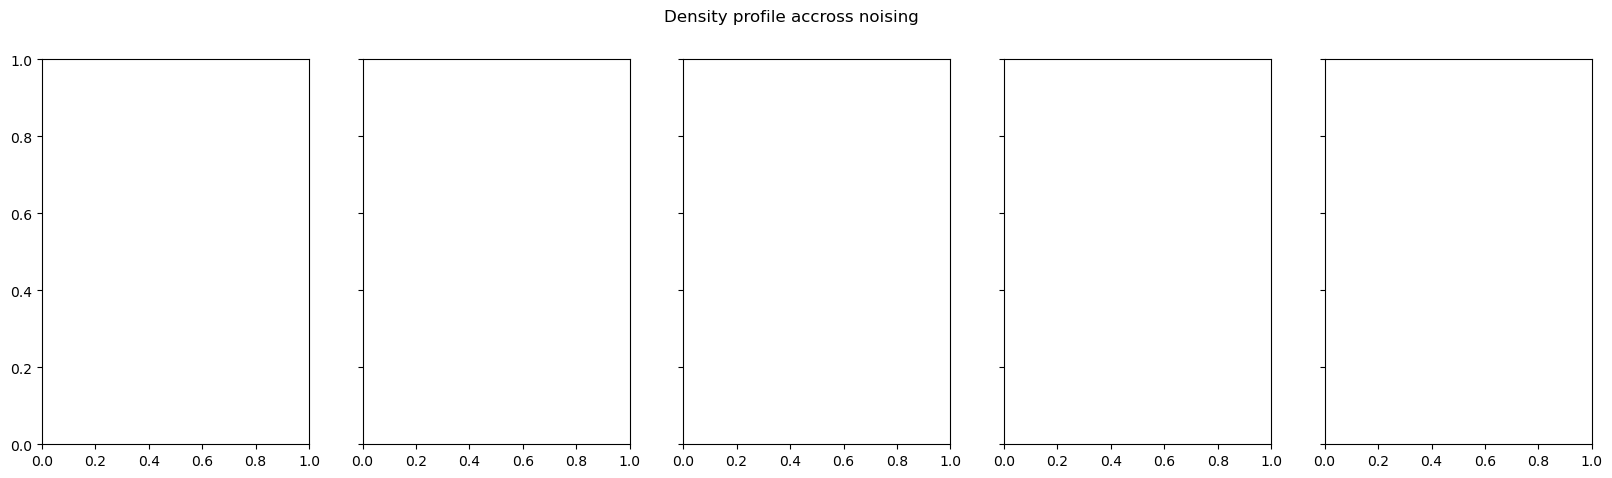

In [223]:
fig, axs = plt.subplots(1, N, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Density profile accross noising')
fd = Noisy.density.flatten(-2)
fd = fd[fd.isnan() == False]
fg = Noisy.density_gradient.flatten(-2)
fg = fg[fd.isnan()  == False]
e_stab = ((fg > 0).sum(axis=1) > 0) # Columns with at least one stratification error
ssbi =  torch.randperm(fd.shape[-1])[:100]

for i in range(N) :
    fds = fd[i, :, ssbi]
    e_stabs = e_stab[i, ssbi]
    fds_v, fds_x = fds[:, e_stabs == True], fds[:, e_stabs == False]
    #axs[i].plot(fds_v,torch.arange(fds_v.shape[0])[:, None].repeat((1,fds_v.shape[1])), alpha=0.2, c='green')
    axs[i].plot(fds_x,torch.arange(fds_x.shape[0])[:, None].repeat((1,fds_x.shape[1])), alpha=1.0, c='red')
    axs[i].set_title(f'St : {ts[i]} Den. Err. : {e_stab.to(float).mean() : .2f}')